In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [88]:
import os
files = os.listdir()
files

['.ipynb_checkpoints',
 'generate_manufacturing_data.py',
 'manufacturing.sql',
 'manufacturing_automotive_cleaned',
 'manufacturing_automotive_raw',
 'Manufacturing_Data_Analysis.ipynb',
 'MFP_Data_Analysis.ipynb']

In [89]:
cleaned_path = "manufacturing_automotive_cleaned"
os.listdir(cleaned_path)

['defect_records.csv',
 'downtime_records.csv',
 'maintenance_records.csv',
 'plants.csv',
 'production_lines.csv',
 'production_records.csv',
 'products.csv',
 'shifts.csv']

In [90]:
production = pd.read_csv("manufacturing_automotive_cleaned/production_records.csv")
downtime = pd.read_csv("manufacturing_automotive_cleaned/downtime_records.csv")
defects = pd.read_csv("manufacturing_automotive_cleaned/defect_records.csv")
maintenance = pd.read_csv("manufacturing_automotive_cleaned/maintenance_records.csv")
plants = pd.read_csv("manufacturing_automotive_cleaned/plants.csv")
production_lines = pd.read_csv("manufacturing_automotive_cleaned/production_lines.csv")
products = pd.read_csv("manufacturing_automotive_cleaned/products.csv")
shifts = pd.read_csv("manufacturing_automotive_cleaned/shifts.csv")

In [91]:
datasets = {
    "Production": production,
    "Downtime": downtime,
    "Defects": defects,
    "Maintenance": maintenance,
    "Plants": plants,
    "Production Lines": production_lines,
    "Products": products,
    "Shifts": shifts
}

dataset_summary = pd.DataFrame({
    "Rows": [df.shape[0] for df in datasets.values()],
    "Columns": [df.shape[1] for df in datasets.values()]
}, index=datasets.keys())

dataset_summary

,Rows,Columns
Production,34985,10
Downtime,12000,7
Defects,8000,6
Maintenance,5000,8
Plants,4,4
Production Lines,20,5
Products,20,4
Shifts,3,4


In [92]:
for name, df in datasets.items():
    print(f"\n{'='*60}")
    print(f"{name.upper()}")
    print(f"{'='*60}")
    print(df.columns.tolist())


PRODUCTION
['production_id', 'production_date', 'plant_id', 'line_id', 'product_id', 'shift_id', 'planned_quantity', 'actual_quantity', 'scrap_quantity', 'operator_id']

DOWNTIME
['downtime_id', 'production_id', 'downtime_start', 'downtime_end', 'downtime_minutes', 'downtime_reason', 'machine_status']

DEFECTS
['defect_id', 'production_id', 'defect_type', 'defect_quantity', 'severity', 'inspection_date']

MAINTENANCE
['maintenance_id', 'plant_id', 'line_id', 'maintenance_date', 'maintenance_type', 'maintenance_duration_minutes', 'maintenance_cost', 'maintenance_status']

PLANTS
['plant_id', 'plant_name', 'city', 'specialty']

PRODUCTION LINES
['line_id', 'plant_id', 'line_name', 'capacity_per_hour', 'specialty']

PRODUCTS
['product_id', 'product_name', 'product_category', 'standard_cycle_time_sec']

SHIFTS
['shift_id', 'shift_name', 'start_time', 'end_time']


In [93]:
for name, df in datasets.items():
    print(f"\n{'='*60}")
    print(f"{name.upper()}")
    print(f"{'='*60}")
    print(df.dtypes)


PRODUCTION
production_id         str
production_date       str
plant_id              str
line_id               str
product_id            str
shift_id              str
planned_quantity    int64
actual_quantity     int64
scrap_quantity      int64
operator_id           str
dtype: object

DOWNTIME
downtime_id           str
production_id         str
downtime_start        str
downtime_end          str
downtime_minutes    int64
downtime_reason       str
machine_status        str
dtype: object

DEFECTS
defect_id            str
production_id        str
defect_type          str
defect_quantity    int64
severity             str
inspection_date      str
dtype: object

MAINTENANCE
maintenance_id                      str
plant_id                            str
line_id                             str
maintenance_date                    str
maintenance_type                    str
maintenance_duration_minutes      int64
maintenance_cost                float64
maintenance_status                  str
dt

In [94]:
production["production_date"] = pd.to_datetime(production["production_date"])
downtime["downtime_start"] = pd.to_datetime(downtime["downtime_start"])
downtime["downtime_end"] = pd.to_datetime(downtime["downtime_end"])
defects["inspection_date"] = pd.to_datetime(defects["inspection_date"])
maintenance["maintenance_date"] = pd.to_datetime(maintenance["maintenance_date"])

In [95]:
print("Production period:", production["production_date"].min(), "to", production["production_date"].max())
print("Downtime period:", downtime["downtime_start"].min(), "to", downtime["downtime_start"].max())
print("Defect period:", defects["inspection_date"].min(), "to", defects["inspection_date"].max())
print("Maintenance period:", maintenance["maintenance_date"].min(), "to", maintenance["maintenance_date"].max())

Production period: 2024-01-01 00:00:00 to 2025-06-30 00:00:00
Downtime period: 2024-01-01 00:50:00 to 2025-06-30 19:15:00
Defect period: 2024-01-01 00:00:00 to 2025-07-03 00:00:00
Maintenance period: 2024-01-01 00:00:00 to 2025-06-30 00:00:00


In [96]:
print("PRODUCTION")
display(production.describe())

print("\nDOWNTIME")
display(downtime.describe())

print("\nDEFECTS")
display(defects.describe())

print("\nMAINTENANCE")
display(maintenance.describe())

PRODUCTION


,production_date,planned_quantity,actual_quantity,scrap_quantity
count,34985,34985.000000,34985.000000,34985.000000
mean,2024-09-29 05:19:56.432757,452.562327,427.000029,6.944633
min,2024-01-01 00:00:00,331.000000,295.000000,0.000000
25%,2024-05-15 00:00:00,415.000000,391.000000,5.000000
50%,2024-09-29 00:00:00,444.000000,420.000000,7.000000
75%,2025-02-13 00:00:00,476.000000,451.000000,9.000000
max,2025-06-30 00:00:00,646.000000,656.000000,18.000000
std,NaN,61.949293,56.824286,2.667763



DOWNTIME


,downtime_start,downtime_end,downtime_minutes
count,12000,12000,12000.000000
mean,2024-09-30 05:19:46.289999,2024-09-30 06:18:45.994999,58.995083
min,2024-01-01 00:50:00,2024-01-01 01:24:00,10.000000
25%,2024-05-15 04:42:15,2024-05-15 05:40:00,36.000000
50%,2024-10-01 04:21:30,2024-10-01 04:50:00,51.000000
75%,2025-02-13 12:46:30,2025-02-13 13:01:15,76.000000
max,2025-06-30 19:15:00,2025-06-30 20:02:00,207.000000
std,NaN,NaN,31.955534



DEFECTS


,defect_quantity,inspection_date
count,8000.000000,8000
mean,3.985625,2024-10-01 18:16:01.200000
min,1.000000,2024-01-01 00:00:00
25%,3.000000,2024-05-17 00:00:00
50%,4.000000,2024-09-30 00:00:00
75%,5.000000,2025-02-17 00:00:00
max,13.000000,2025-07-03 00:00:00
std,1.739194,NaN



MAINTENANCE


,maintenance_date,maintenance_duration_minutes,maintenance_cost
count,5000,5000.000000,5000.000000
mean,2024-10-01 20:32:55.680000,72.873000,4298.788282
min,2024-01-01 00:00:00,10.000000,273.820000
25%,2024-05-19 00:00:00,42.000000,1825.312500
50%,2024-09-30 12:00:00,64.000000,2933.110000
75%,2025-02-17 00:00:00,93.000000,6191.057500
max,2025-06-30 00:00:00,249.000000,18018.850000
std,NaN,41.506855,3580.577627


In [97]:
production["production_gap"] = (
    production["planned_quantity"] - production["actual_quantity"])

production["achievement_rate"] = (
    production["actual_quantity"] / production["planned_quantity"] * 100)

production[["planned_quantity", "actual_quantity", "production_gap", "achievement_rate"]].head()

,planned_quantity,actual_quantity,production_gap,achievement_rate
0,473,444,29,93.868922
1,463,435,28,93.952484
2,431,399,32,92.575406
3,465,426,39,91.612903
4,385,364,21,94.545455


In [98]:
total_planned = production["planned_quantity"].sum()
total_actual = production["actual_quantity"].sum()
total_gap = production["production_gap"].sum()

overall_achievement = (total_actual / total_planned) * 100

print(f"Total Planned Production : {total_planned:,} units")
print(f"Total Actual Production  : {total_actual:,} units")
print(f"Total Production Gap     : {total_gap:,} units")
print(f"Overall Achievement Rate : {overall_achievement:.2f}%")

Total Planned Production : 15,832,893 units
Total Actual Production  : 14,938,596 units
Total Production Gap     : 894,297 units
Overall Achievement Rate : 94.35%


In [99]:
plant_performance = (
    production.groupby("plant_id")
    .agg(
        planned_quantity=("planned_quantity", "sum"),
        actual_quantity=("actual_quantity", "sum"),
        production_gap=("production_gap", "sum"))
    .reset_index())

plant_performance["achievement_rate"] = (
    plant_performance["actual_quantity"]
    / plant_performance["planned_quantity"]
    * 100)

plant_performance = plant_performance.sort_values(
    "achievement_rate",
    ascending=False)

plant_performance

,plant_id,planned_quantity,actual_quantity,production_gap,achievement_rate
0,P01,3584446,3468215,116231,96.757351
2,P03,3167208,3005039,162169,94.879749
3,P04,3798208,3563168,235040,93.811819
1,P02,5283031,4902174,380857,92.790938


In [100]:
line_performance = (
    production.groupby("line_id")
    .agg(
        planned_quantity=("planned_quantity", "sum"),
        actual_quantity=("actual_quantity", "sum"),
        production_gap=("production_gap", "sum"))
    .reset_index())

line_performance["achievement_rate"] = (
    line_performance["actual_quantity"]
    / line_performance["planned_quantity"]
    * 100)

line_performance = line_performance.sort_values(
    "achievement_rate",
    ascending=False)

line_performance

,line_id,planned_quantity,actual_quantity,production_gap,achievement_rate
3,L04,740033,716324,23709,96.796224
4,L05,723895,700608,23287,96.783097
1,L02,791600,765947,25653,96.759348
0,L01,603928,584275,19653,96.745804
2,L03,724990,701061,23929,96.699403
12,L13,611225,581384,29841,95.117837
10,L11,562923,534531,28392,94.956326
11,L12,694943,659672,35271,94.924620
13,L14,646017,611912,34105,94.720727
14,L15,652100,617540,34560,94.700199


In [101]:
line_performance = line_performance.merge(
    production_lines[
        ["line_id", "plant_id", "line_name", "capacity_per_hour", "specialty"]],
    on="line_id",
    how="left")

line_performance

,line_id,planned_quantity,actual_quantity,production_gap,achievement_rate,plant_id,line_name,capacity_per_hour,specialty
0,L04,740033,716324,23709,96.796224,P01,Chennai Line 4,54,Engine & Drivetrain
1,L05,723895,700608,23287,96.783097,P01,Chennai Line 5,54,Engine & Drivetrain
2,L02,791600,765947,25653,96.759348,P01,Chennai Line 2,61,Engine & Drivetrain
3,L01,603928,584275,19653,96.745804,P01,Chennai Line 1,46,Engine & Drivetrain
4,L03,724990,701061,23929,96.699403,P01,Chennai Line 3,58,Engine & Drivetrain
5,L13,611225,581384,29841,95.117837,P03,Bengaluru Line 3,55,Steering & Suspension
6,L11,562923,534531,28392,94.956326,P03,Bengaluru Line 1,51,Steering & Suspension
7,L12,694943,659672,35271,94.924620,P03,Bengaluru Line 2,60,Steering & Suspension
8,L14,646017,611912,34105,94.720727,P03,Bengaluru Line 4,55,Steering & Suspension
9,L15,652100,617540,34560,94.700199,P03,Bengaluru Line 5,55,Steering & Suspension


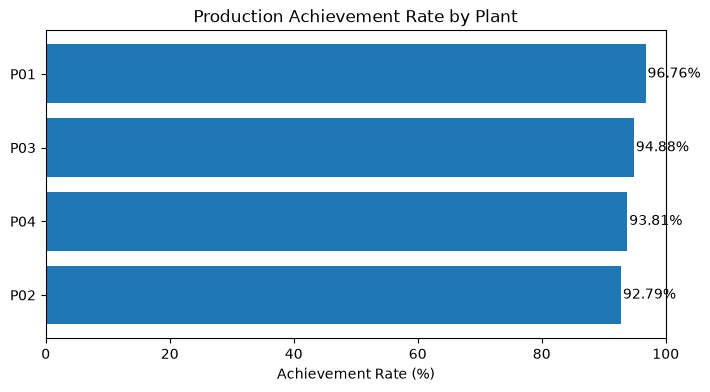

In [102]:
plant_chart = plant_performance.sort_values("achievement_rate")
plt.figure(figsize=(8, 4))
bars = plt.barh(plant_chart["plant_id"], plant_chart["achievement_rate"])
plt.xlabel("Achievement Rate (%)")
plt.title("Production Achievement Rate by Plant")
plt.xlim(0, 100)

for bar in bars:
    plt.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.2f}%",
        va="center")

plt.show()

In [103]:
print("Total Downtime Events :", len(downtime))
print("Total Downtime Minutes:", downtime["downtime_minutes"].sum())
print("Average Downtime/Event:", round(downtime["downtime_minutes"].mean(), 2))

Total Downtime Events : 12000
Total Downtime Minutes: 707941
Average Downtime/Event: 59.0


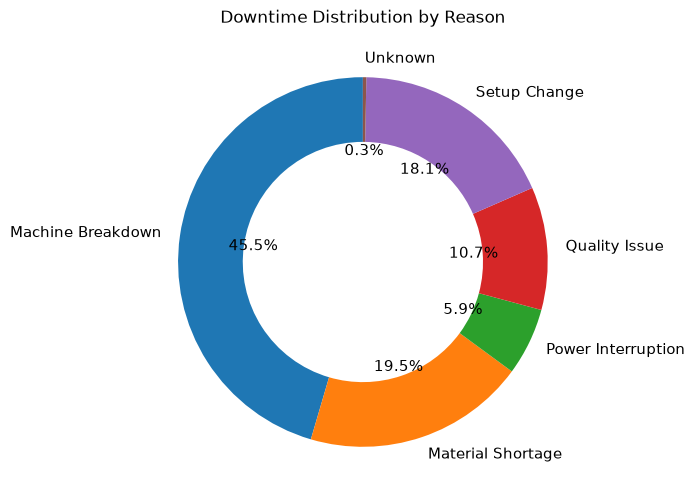

In [104]:
reason_downtime = downtime.groupby("downtime_reason")["downtime_minutes"].sum()
plt.figure(figsize=(6, 6))
plt.pie(
    reason_downtime,
    labels=reason_downtime.index,
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 11},
    wedgeprops={"width": 0.35})

plt.title("Downtime Distribution by Reason")
plt.show()

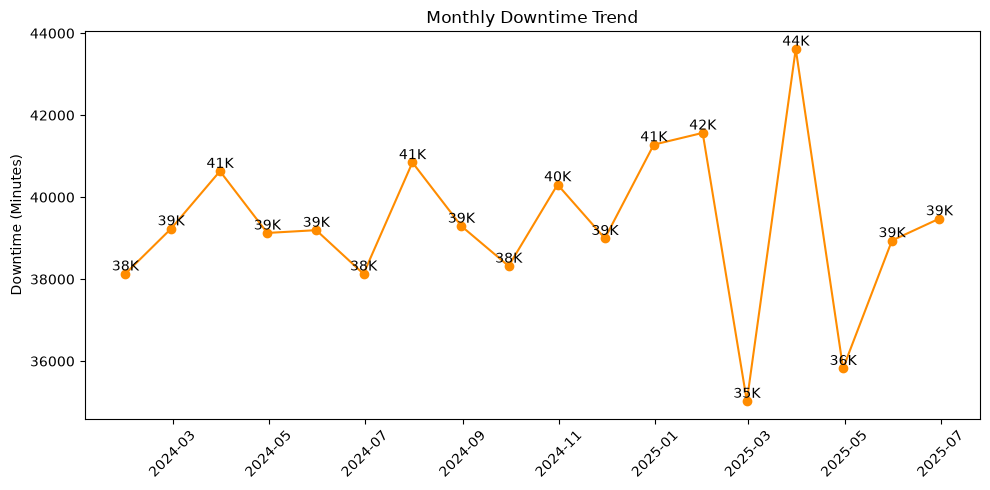

In [105]:
monthly_downtime = downtime.set_index("downtime_start")["downtime_minutes"].resample("ME").sum()

plt.figure(figsize=(10,5))
plt.plot(monthly_downtime.index, monthly_downtime.values, marker="o", color="darkorange")

plt.title("Monthly Downtime Trend")
plt.ylabel("Downtime (Minutes)")
plt.xticks(rotation=45)

for x, y in zip(monthly_downtime.index, monthly_downtime.values):
    plt.text(x, y, f"{y/1000:.0f}K", ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [106]:
downtime_plant = downtime.merge(
    production[["production_id", "plant_id"]],
    on="production_id")

<Figure size 900x500 with 0 Axes>

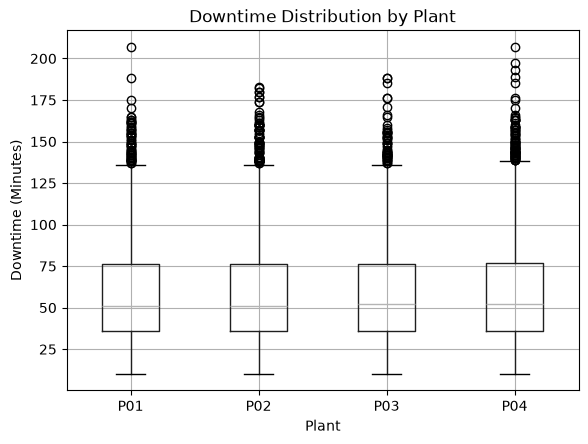

In [107]:
plt.figure(figsize=(9,5))
downtime_plant.boxplot(column="downtime_minutes", by="plant_id")
plt.title("Downtime Distribution by Plant")
plt.suptitle("")
plt.xlabel("Plant")
plt.ylabel("Downtime (Minutes)")
plt.show()

In [108]:
status_reason = pd.crosstab(downtime["downtime_reason"], downtime["machine_status"])
status_reason

machine_status,Idle,Stopped,Under Repair
downtime_reason,,,
Machine Breakdown,500,2047,853
Material Shortage,346,1361,628
Power Interruption,224,822,356
Quality Issue,309,1138,473
Setup Change,426,1780,707
Unknown,9,13,8


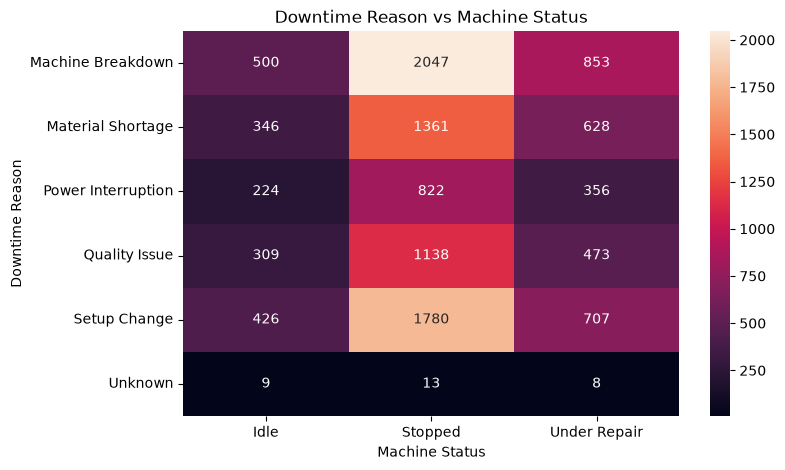

In [109]:
plt.figure(figsize=(8,5))
sns.heatmap(status_reason, annot=True, fmt="d")
plt.title("Downtime Reason vs Machine Status")
plt.xlabel("Machine Status")
plt.ylabel("Downtime Reason")
plt.show()

In [110]:
downtime_shift = downtime.merge(
    production[["production_id", "shift_id"]],
    on="production_id").merge(
    shifts[["shift_id", "shift_name"]],
    on="shift_id")

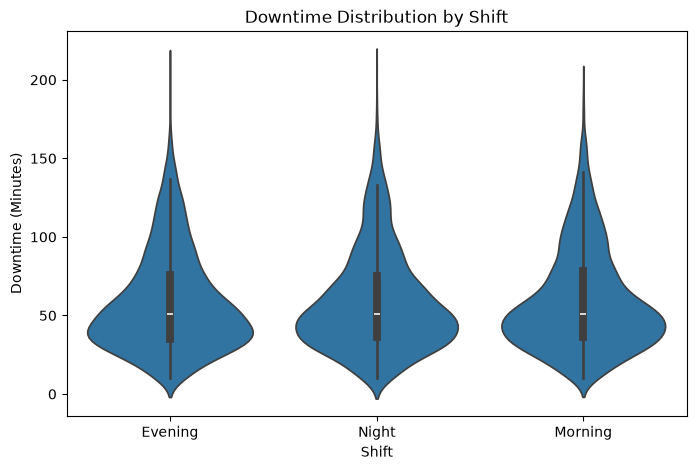

In [111]:
plt.figure(figsize=(8,5))
sns.violinplot(data=downtime_shift, x="shift_name", y="downtime_minutes")
plt.title("Downtime Distribution by Shift")
plt.xlabel("Shift")
plt.ylabel("Downtime (Minutes)")
plt.show()

In [112]:
maintenance_type = maintenance.groupby("maintenance_type").agg(
    duration=("maintenance_duration_minutes", "sum"),
    cost=("maintenance_cost", "sum"))
maintenance_type

,duration,cost
maintenance_type,,
Corrective,180876,13561642.04
Inspection,21641,649487.25
Preventive,161848,7282812.12


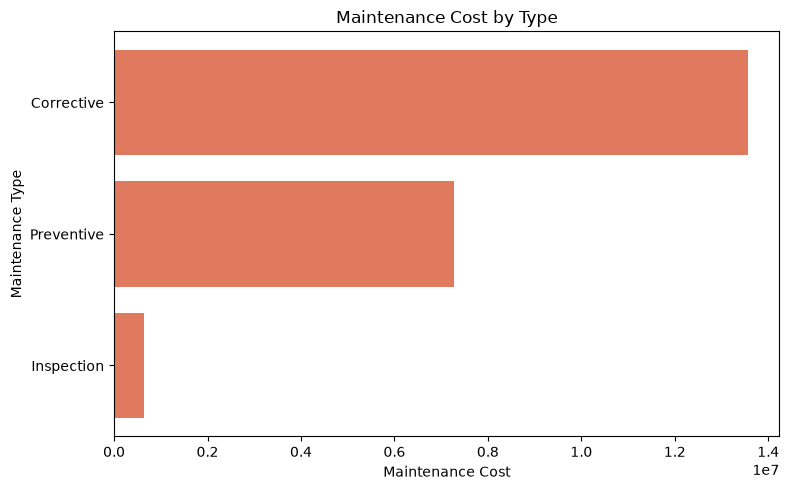

In [113]:
plt.figure(figsize=(8,5))
maintenance_cost = (
    maintenance.groupby("maintenance_type")["maintenance_cost"]
    .sum()
    .sort_values(ascending=True))

plt.barh(
    maintenance_cost.index,
    maintenance_cost.values,
    color="#E07A5F")

plt.title("Maintenance Cost by Type")
plt.xlabel("Maintenance Cost")
plt.ylabel("Maintenance Type")

plt.tight_layout()
plt.show()

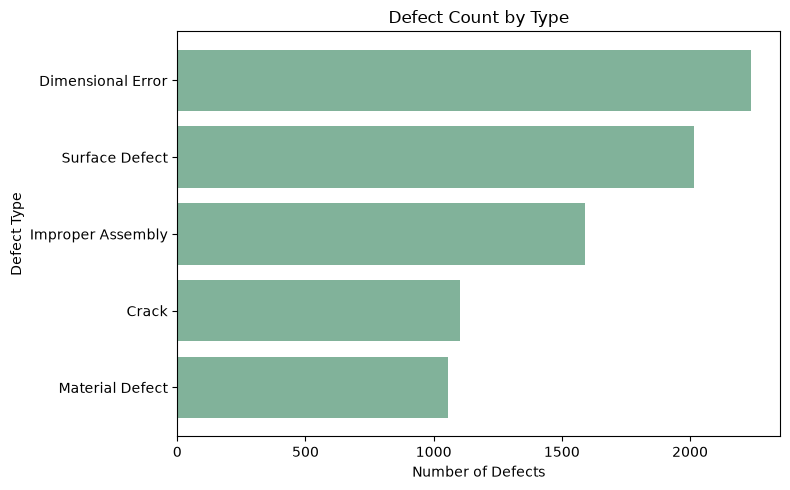

In [114]:
plt.figure(figsize=(8,5))
defect_counts = (
    defects["defect_type"]
    .value_counts()
    .sort_values(ascending=True))
plt.barh(
    defect_counts.index,
    defect_counts.values,
    color="#81B29A")

plt.title("Defect Count by Type")
plt.xlabel("Number of Defects")
plt.ylabel("Defect Type")

plt.tight_layout()
plt.show()

In [115]:
defects.columns

Index(['defect_id', 'production_id', 'defect_type', 'defect_quantity',
       'severity', 'inspection_date'],
      dtype='str')

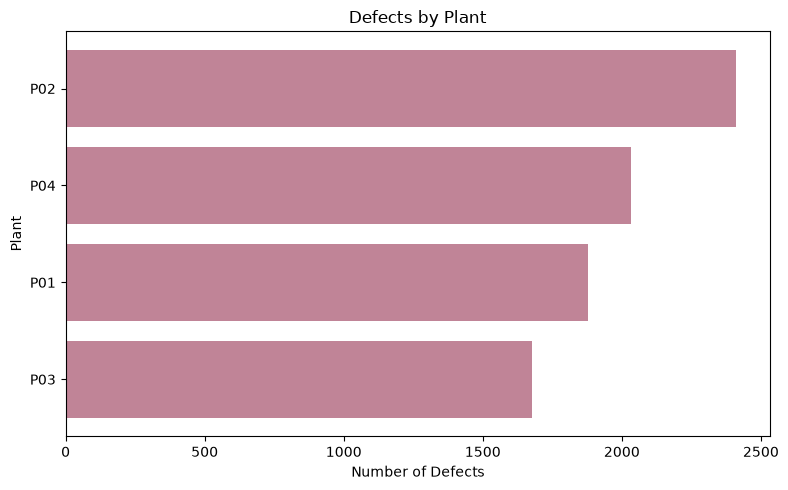

In [116]:
plt.figure(figsize=(8,5))

defect_by_plant = (
    defects.merge(
        production[["production_id", "plant_id"]],
        on="production_id",
        how="left")
    .groupby("plant_id")
    .size()
    .sort_values(ascending=True))

plt.barh(
    defect_by_plant.index,
    defect_by_plant.values,
    color="#C08497")

plt.title("Defects by Plant")
plt.xlabel("Number of Defects")
plt.ylabel("Plant")

plt.tight_layout()
plt.show()

In [117]:
%whos DataFrame

Variable             Type         Data/Info
-------------------------------------------
dataset_summary      DataFrame    Shape: (8, 2)
defects              DataFrame    Shape: (8000, 6)
df                   DataFrame    Shape: (3, 4)
downtime             DataFrame    Shape: (12000, 7)
downtime_plant       DataFrame    Shape: (12000, 8)
downtime_shift       DataFrame    Shape: (12000, 9)
line_performance     DataFrame    Shape: (20, 9)
maintenance          DataFrame    Shape: (5000, 8)
maintenance_type     DataFrame    Shape: (3, 2)
plant_chart          DataFrame    Shape: (4, 5)
plant_performance    DataFrame    Shape: (4, 5)
plants               DataFrame    Shape: (4, 4)
production           DataFrame    Shape: (34985, 12)
production_defects   DataFrame    Shape: (8000, 7)
production_lines     DataFrame    Shape: (20, 5)
products             DataFrame    Shape: (20, 4)
shifts               DataFrame    Shape: (3, 4)
status_reason        DataFrame    Shape: (6, 3)


In [118]:
production.columns

Index(['production_id', 'production_date', 'plant_id', 'line_id', 'product_id',
       'shift_id', 'planned_quantity', 'actual_quantity', 'scrap_quantity',
       'operator_id', 'production_gap', 'achievement_rate'],
      dtype='str')

In [119]:
production_lines.columns

Index(['line_id', 'plant_id', 'line_name', 'capacity_per_hour', 'specialty'], dtype='str')

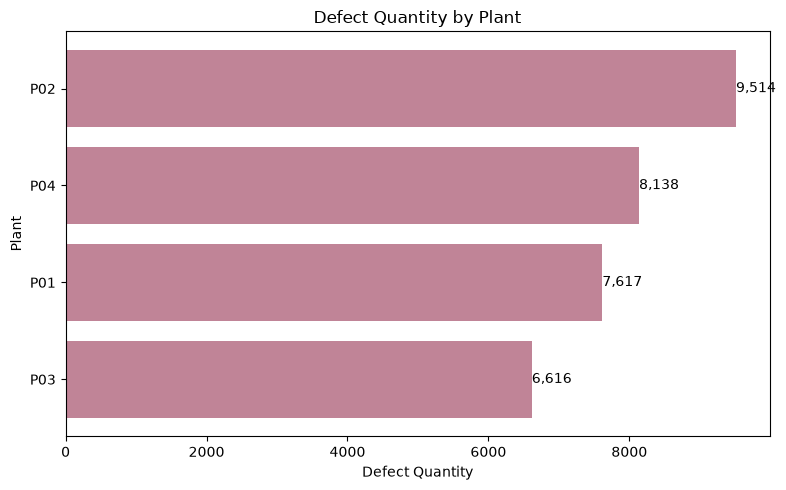

In [120]:
plt.figure(figsize=(8,5))

d = defects.merge(production[["production_id","plant_id"]], on="production_id") \
           .groupby("plant_id")["defect_quantity"].sum().sort_values()

bars = plt.barh(d.index, d.values, color="#C08497")

for bar in bars:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
             f"{bar.get_width():,.0f}", va="center")

plt.title("Defect Quantity by Plant")
plt.xlabel("Defect Quantity")
plt.ylabel("Plant")
plt.tight_layout()
plt.show()

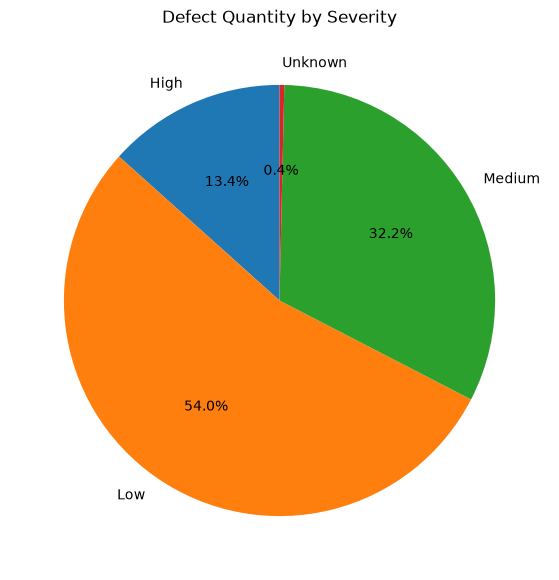

In [121]:
plt.figure(figsize=(7,7))
d = defects.groupby("severity")["defect_quantity"].sum()
plt.pie(
    d.values,
    labels=d.index,
    autopct="%1.1f%%",
    startangle=90)

plt.title("Defect Quantity by Severity")
plt.show()

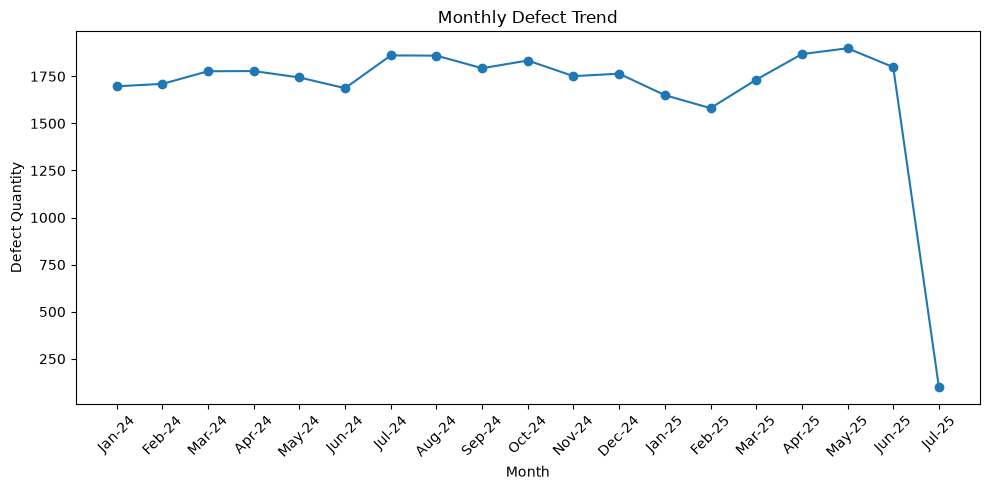

In [122]:
plt.figure(figsize=(10,5))

d = defects.groupby(defects["inspection_date"].dt.to_period("M"))["defect_quantity"].sum()

plt.plot(d.index.strftime("%b-%y"), d.values, marker="o")

plt.title("Monthly Defect Trend")
plt.xlabel("Month")
plt.ylabel("Defect Quantity")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

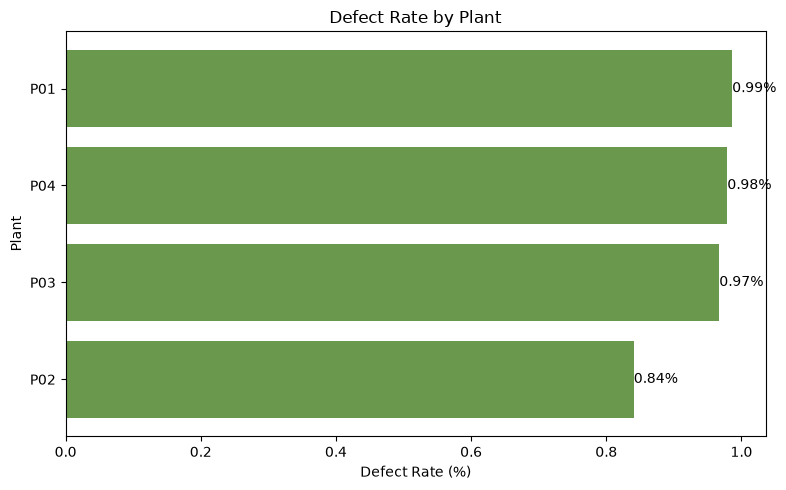

In [123]:
d = defects.merge(production[["production_id","plant_id","actual_quantity"]],
                  on="production_id").groupby("plant_id").agg(
                  defects=("defect_quantity","sum"),
                  production=("actual_quantity","sum"))

d["rate"] = d.defects / d.production * 100
d = d.rate.sort_values()

plt.figure(figsize=(8,5))
bars = plt.barh(d.index, d.values, color="#6A994E")

for bar in bars:
    plt.text(bar.get_width(), bar.get_y()+bar.get_height()/2,
             f"{bar.get_width():.2f}%", va="center")

plt.title("Defect Rate by Plant")
plt.xlabel("Defect Rate (%)")
plt.ylabel("Plant")
plt.tight_layout()
plt.show()

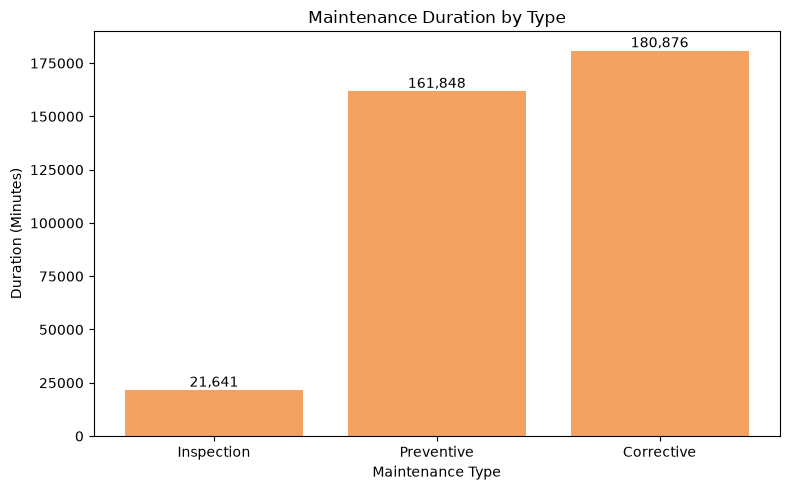

In [124]:
d = maintenance.groupby("maintenance_type")["maintenance_duration_minutes"].sum().sort_values()

plt.figure(figsize=(8,5))
bars = plt.bar(d.index, d.values, color="#F4A261")

for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height(),
             f"{bar.get_height():,.0f}", ha="center", va="bottom")

plt.title("Maintenance Duration by Type")
plt.xlabel("Maintenance Type")
plt.ylabel("Duration (Minutes)")
plt.tight_layout()
plt.show()

In [125]:
downtime_plant.columns

Index(['downtime_id', 'production_id', 'downtime_start', 'downtime_end',
       'downtime_minutes', 'downtime_reason', 'machine_status', 'plant_id'],
      dtype='str')

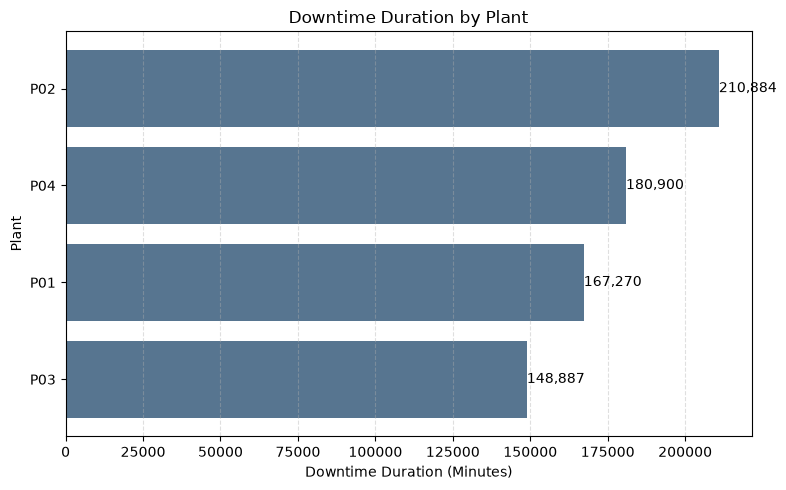

In [126]:
d = downtime_plant.groupby("plant_id")["downtime_minutes"].sum().sort_values()
plt.figure(figsize=(8,5))
bars = plt.barh(d.index, d.values, color="#577590")
for bar in bars:
    plt.text(bar.get_width(), bar.get_y()+bar.get_height()/2,
             f"{bar.get_width():,.0f}", va="center")

plt.title("Downtime Duration by Plant")
plt.xlabel("Downtime Duration (Minutes)")
plt.ylabel("Plant")
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

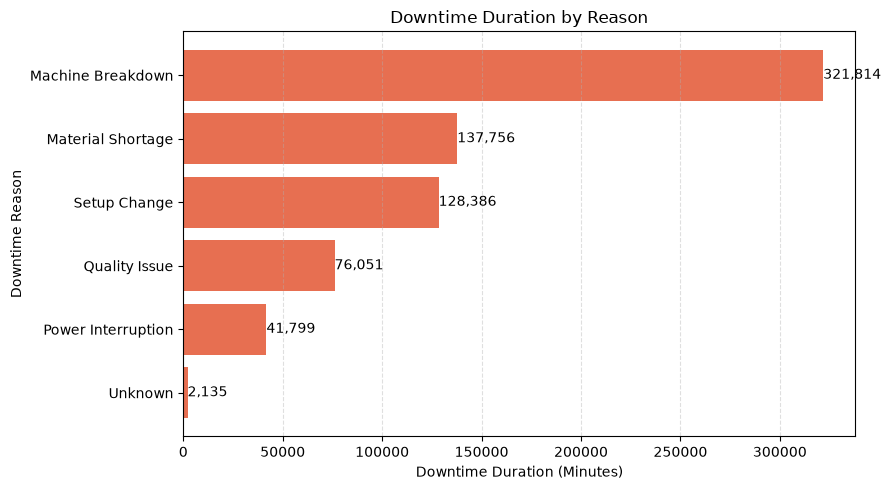

In [127]:
d = downtime.groupby("downtime_reason")["downtime_minutes"].sum().sort_values()
plt.figure(figsize=(9,5))
bars = plt.barh(d.index, d.values, color="#E76F51")
for bar in bars:
    plt.text(bar.get_width(), bar.get_y()+bar.get_height()/2,
             f"{bar.get_width():,.0f}", va="center")

plt.title("Downtime Duration by Reason")
plt.xlabel("Downtime Duration (Minutes)")
plt.ylabel("Downtime Reason")
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

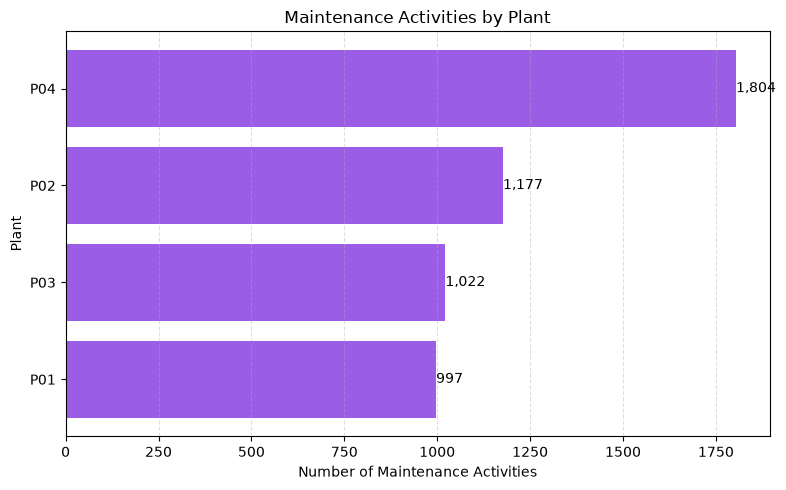

In [128]:
d = maintenance.groupby("plant_id").size().sort_values()
plt.figure(figsize=(8,5))
bars = plt.barh(d.index, d.values, color="#9B5DE5")
for bar in bars:
    plt.text(bar.get_width(), bar.get_y()+bar.get_height()/2,
             f"{bar.get_width():,.0f}", va="center")

plt.title("Maintenance Activities by Plant")
plt.xlabel("Number of Maintenance Activities")
plt.ylabel("Plant")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [129]:
%whos DataFrame

Variable             Type         Data/Info
-------------------------------------------
dataset_summary      DataFrame    Shape: (8, 2)
defects              DataFrame    Shape: (8000, 6)
df                   DataFrame    Shape: (3, 4)
downtime             DataFrame    Shape: (12000, 7)
downtime_plant       DataFrame    Shape: (12000, 8)
downtime_shift       DataFrame    Shape: (12000, 9)
line_performance     DataFrame    Shape: (20, 9)
maintenance          DataFrame    Shape: (5000, 8)
maintenance_type     DataFrame    Shape: (3, 2)
plant_chart          DataFrame    Shape: (4, 5)
plant_performance    DataFrame    Shape: (4, 5)
plants               DataFrame    Shape: (4, 4)
production           DataFrame    Shape: (34985, 12)
production_defects   DataFrame    Shape: (8000, 7)
production_lines     DataFrame    Shape: (20, 5)
products             DataFrame    Shape: (20, 4)
shifts               DataFrame    Shape: (3, 4)
status_reason        DataFrame    Shape: (6, 3)


In [130]:
for name in ["plant_performance", "line_performance", "downtime_plant",
             "downtime_shift", "maintenance_type", "production_defects",
             "status_reason", "plant_chart"]:
    print("\n", name)
    print(globals()[name].columns.tolist())


 plant_performance
['plant_id', 'planned_quantity', 'actual_quantity', 'production_gap', 'achievement_rate']

 line_performance
['line_id', 'planned_quantity', 'actual_quantity', 'production_gap', 'achievement_rate', 'plant_id', 'line_name', 'capacity_per_hour', 'specialty']

 downtime_plant
['downtime_id', 'production_id', 'downtime_start', 'downtime_end', 'downtime_minutes', 'downtime_reason', 'machine_status', 'plant_id']

 downtime_shift
['downtime_id', 'production_id', 'downtime_start', 'downtime_end', 'downtime_minutes', 'downtime_reason', 'machine_status', 'shift_id', 'shift_name']

 maintenance_type
['duration', 'cost']

 production_defects
['defect_id', 'production_id', 'defect_type', 'defect_quantity', 'severity', 'inspection_date', 'actual_quantity']

 status_reason
['Idle', 'Stopped', 'Under Repair']

 plant_chart
['plant_id', 'planned_quantity', 'actual_quantity', 'production_gap', 'achievement_rate']


In [131]:
py_downtime = downtime_plant.groupby("plant_id").agg(
    downtime_minutes=("downtime_minutes", "sum")
).reset_index()

py_defects = production_defects.groupby("defect_type").agg(
    defect_quantity=("defect_quantity", "sum")
).reset_index()

In [132]:
path = r"E:\Data verse projects\Manufacturing_project"

plant_performance.to_csv(path + r"\PY_Plant_Performance.csv", index=False)
line_performance.to_csv(path + r"\PY_Line_Performance.csv", index=False)
maintenance_type.to_csv(path + r"\PY_Maintenance_Type.csv", index=False)
status_reason.to_csv(path + r"\PY_Status_Reason.csv", index=False)
py_downtime.to_csv(path + r"\PY_Downtime_Analysis.csv", index=False)
py_defects.to_csv(path + r"\PY_Defect_Analysis.csv", index=False)

print("Python analysis files saved successfully!")

Python analysis files saved successfully!
